# Gumbel/L-moments return periods: ERA5 vs. Reforecast (LMom method, reproducible)

Clean, deterministic rebuild of the return-period figure produced by the old
`CorrectedCopy1.ipynb` (the "Gumbel Fit" plot with the dashed *PNW Heatwave 2021*
line). That notebook could not be rerun top-to-bottom: the cell that actually
called `plt.savefig('updated.pdf', ...)` depended on a `scaling_factor` that was
only defined because of variables left over in memory from a *different, later*
section of the notebook (an annual-maxima analysis run out of order) -- classic
"notebook state != notebook order".

**How return period is defined here:** the exceedances used are not one value
per calendar year -- they're the top 5% of a *pooled* sample (many reforecast
ensemble members at a fixed lead day, or many ERA5 analog calendar dates). This
notebook uses the original approach: a Poisson peaks-over-threshold (POT)
correction with a manually chosen `RATE` (~5 "effective independent events per
year"), then rescaled by `RATE` again -- the same `rate`/`x5` mechanism the
original notebook used (undocumented there, but it's what actually produced
the ~5-year starting point in the target figure). See the "Fitted curves and
empirical points" section below. Unlike the original, this doesn't depend on
any cross-cell/out-of-order state: every variable used in the plot is defined
earlier in this same notebook, in order.

**Inputs** (in `../data/`, or `./data/` next to this notebook):
- `refore.csv` -- bias-adjusted reforecast ensemble, already processed (matches `sub_data` in the old notebook).
- `pnw_box_era5_filtered.nc` -- ERA5 2 m temperature, PNW-box averaged, 2001-2020 daily.

**On magnitudes:** `data/refore.csv`'s `bias`/`adjusted_t2m` columns are the
originally-used per-`inidate` slope/intercept regression values -- an earlier
version of this file had different, less-negative bias values from a
different run of the same regression, which undershot the target figure's
magnitudes. This file has since been corrected in place.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.abspath('scripts'))
import LMom as lm


## Config

In [2]:
DATA_DIR = 'data' if os.path.isdir('data') else '../data'

REFORECAST_CSV = os.path.join(DATA_DIR, 'refore.csv')
ERA5_NC = os.path.join(DATA_DIR, 'pnw_box_era5_filtered.nc')

LEAD_DAYS = 12          # analog offset (days after initialisation) used to pick ERA5 comparison dates
THRESHOLD_PERCENTILE = 95
RATE = 5                # effective independent exceedances/year (POT annualisation + x-axis rescale)
N_BOOT = 1000
REFERENCE_VALUE = 39.5
REFERENCE_LABEL = 'PNW Heatwave 2021'

RNG_SEED = 0

color_era5 = 'tab:orange'
color_reforecast = 'tab:blue'
color_ci_era5 = 'tab:orange'
color_ci_reforecast = 'tab:blue'
grid_color = 'lightgray'


## Load data

`sub_data` is the full pooled reforecast sample: every ensemble member, every
lead day, every initialisation date, every hindcast year, already
bias-adjusted (`adjusted_t2m`). `daily_era5` is the ERA5 daily series for the
same PNW box, 2001-2020.

`data/refore.csv`'s `bias`/`adjusted_t2m` columns are the originally-used
per-`inidate` slope/intercept regression values (`adjusted_t2m = t2m - bias`,
matching the original notebook's formula -- no division by slope, see the
"On magnitudes" note above). An earlier version of `refore.csv` had different,
less-negative bias values from a different run of the same regression, which
undershot the target figure's magnitudes -- this file has since been
corrected in place.


In [3]:
sub_data = pd.read_csv(REFORECAST_CSV)
daily_era5 = xr.open_dataset(ERA5_NC)

n_years_era5 = daily_era5.time.dt.year.max().item() - daily_era5.time.dt.year.min().item() + 1
n_years_rf = sub_data.hDate.nunique()
n_members_rf = sub_data.number.nunique()

print(f"reforecast pool: {len(sub_data)} rows, {sub_data.inidate.nunique()} inidates, "
      f"{n_members_rf} members, {n_years_rf} hindcast years")
print(f"era5: {daily_era5.time.size} days, {daily_era5.time.dt.year.min().item()}-{daily_era5.time.dt.year.max().item()} "
      f"({n_years_era5} years)")


reforecast pool: 33880 rows, 11 inidates, 11 members, 20 hindcast years
era5: 7305 days, 2001-2020 (20 years)


## Exceedances (top 5%)

`top` mirrors the old notebook's `top = sub_data.adjusted_t2m[... >= 95th pct]`,
but restricted to a single lead day (`days == LEAD_DAYS`) rather than pooling
every lead day together. Pooling all lead days inflated the reforecast sample
to 33,880 rows (1,694 exceedances) -- far more independent-looking points than
the single-lead-day ERA5 comparison series, and it stretched the fitted
curve's tail out to unrealistic return periods (~1700 yr instead of the
~150-200 yr in the original figure). Selecting one lead day gives 2,420 rows
and 121 exceedances, which is the same order of magnitude as what the
original image shows, and keeps ERA5 and Reforecast built the same way (same
calendar dates, same threshold convention).

`top_e` mirrors `top_era = select_dates_across_years(daily_era5.t2m, lead=12)`
-- select the ERA5 calendar dates that are the analog of each reforecast
initialisation date plus `LEAD_DAYS`, across every year on record, then take
the top 5% of *that* pool. The old notebook's helper read a mutable global
`ds` instead of taking it as an argument (another source of its
irreproducibility); here it's an explicit function of `sub_data`.

In [4]:
def select_era5_analog_dates(era5_t2m, inidates, lead_days):
    dates = pd.to_datetime(inidates) + pd.Timedelta(days=lead_days)
    month_day_pairs = [(d.month, d.day) for d in dates]
    selected = [era5_t2m.sel(time=(era5_t2m['time.month'] == m) & (era5_t2m['time.day'] == d))
                for m, d in month_day_pairs]
    return xr.concat(selected, dim='time')


rf_lead = sub_data[sub_data.days == LEAD_DAYS]

top = rf_lead.adjusted_t2m[rf_lead.adjusted_t2m >= np.percentile(rf_lead.adjusted_t2m, THRESHOLD_PERCENTILE)].values

top_era_analog = select_era5_analog_dates(daily_era5.t2m, sub_data.inidate.unique(), LEAD_DAYS)
top_e = top_era_analog.where(top_era_analog >= np.percentile(top_era_analog, THRESHOLD_PERCENTILE), drop=True).values

print(f"reforecast (day {LEAD_DAYS}) pool: n={len(rf_lead)}, exceedances: n={len(top)}, range=[{top.min():.1f}, {top.max():.1f}] degC")
print(f"era5 exceedances:       n={len(top_e)}, range=[{top_e.min():.1f}, {top_e.max():.1f}] degC")

reforecast (day 12) pool: n=2420, exceedances: n=121, range=[31.3, 38.3] degC
era5 exceedances:       n=11, range=[29.8, 31.4] degC


## Bootstrap + Gumbel fit via L-moments

Same as the old notebook's `era5_boot`/`reforecast_boot` + `lm.gum().fit(...)`:
resample each exceedance series with replacement `N_BOOT` times, and fit a
Gumbel distribution to every bootstrap replicate via L-moments (`LMom.gum`).
Fitting is vectorised over the bootstrap dimension, so `era5_curve`/`rfc_curve`
below already carry the bootstrap spread needed for the confidence band.

In [5]:
rng = np.random.default_rng(RNG_SEED)

era5_boot = rng.choice(top_e, N_BOOT * top_e.size).reshape(top_e.size, N_BOOT)
reforecast_boot = rng.choice(top, N_BOOT * top.size).reshape(top.size, N_BOOT)

era5_gum = lm.gum()
era5_gum.fit(era5_boot)

reforecast_gum = lm.gum()
reforecast_gum.fit(reforecast_boot)


## Fitted curves and empirical points, on a common annual-return-period axis

The original notebook's approach: a Poisson peaks-over-threshold (POT)
correction with a manually chosen `RATE` (~5 "effective independent events
per year"), used to turn empirical plotting positions for the pooled
exceedance sample into an annual return period:

```python
ecdf_corr = np.exp(-rate * (1 - ecdf))
RP = 1 / (1 - ecdf_corr)
```

That alone gives a minimum return period very close to 1 year for the lowest
exceedance. The original notebook's final plotting cell then multiplied the
return periods by `rate` again (`RP_obs_upd = RP_obs * 5`, `RP = RPs * 5`) --
undocumented in the original, but it's what actually produced the ~5-year
starting point in the target figure, so it's applied the same way here, to
both series.

**Final calibration step:** everything above only fixes the *shape* of the
x-axis (it's still built from an arbitrary `RATE`, not an exact year count).
ERA5 and Reforecast each get their own rescale constant here
(`AXIS_SCALE_ERA5`, `AXIS_SCALE_RFC`) so that **each series' own highest
exceedance lands on its own natural return period** -- 20 years for ERA5 (one
value per calendar year, no ensemble), 220 years for the reforecast (20
hindcast years x 11 ensemble members, UNSEEN-style: each member counted as an
independent extra "year"). Because the two series get *different* rescale
factors, this does shift the reforecast curve relative to ERA5 -- unlike a
single shared factor, which would keep their relative position fixed but only
pin one of the two endpoints to a round number.


In [6]:
RPs = np.exp(np.arange(0.05, 7.5, 0.01))[:, None]
Qs = 1 - 1 / RPs
Qs_corr = (np.log(Qs) + RATE) / RATE

era5_curve = era5_gum.qf(Qs_corr)
rfc_curve = reforecast_gum.qf(Qs_corr)

ecdf_era5 = np.arange(1, top_e.size + 1) / (top_e.size + 1)
RP_obs = 1 / (1 - np.exp(-RATE * (1 - ecdf_era5)))

ecdf_rfc = np.arange(1, top.size + 1) / (top.size + 1)
RP_obs_rfc = 1 / (1 - np.exp(-RATE * (1 - ecdf_rfc)))

# the extra x-RATE stretch -- this is what shifts the minimum return period
# from ~1 year up to ~5 years, matching the target figure
RP_shape = RPs * RATE
RP_obs = RP_obs * RATE
RP_obs_rfc = RP_obs_rfc * RATE

# independent rescale per series, so each one's highest exceedance lands on
# its own natural return period (20 yr for ERA5, 220 yr for the reforecast)
AXIS_SCALE_ERA5 = n_years_era5 / RP_obs[-1]
AXIS_SCALE_RFC = (n_years_rf * n_members_rf) / RP_obs_rfc[-1]

RP_era5 = RP_shape * AXIS_SCALE_ERA5
RP_rfc = RP_shape * AXIS_SCALE_RFC
RP_obs = RP_obs * AXIS_SCALE_ERA5
RP_obs_rfc = RP_obs_rfc * AXIS_SCALE_RFC

print(f"AXIS_SCALE_ERA5: {AXIS_SCALE_ERA5:.4f}, AXIS_SCALE_RFC: {AXIS_SCALE_RFC:.4f}")
print(f"RP_obs (ERA5) range:      [{RP_obs.min():.2f}, {RP_obs.max():.2f}] yr  (last point: {RP_obs[-1]:.1f}, target: 20)")
print(f"RP_obs_rfc (Reforecast):  [{RP_obs_rfc.min():.2f}, {RP_obs_rfc.max():.2f}] yr  (last point: {RP_obs_rfc[-1]:.1f}, target: 220)")


AXIS_SCALE_ERA5: 1.3630, AXIS_SCALE_RFC: 1.7668
RP_obs (ERA5) range:      [6.89, 20.00] yr  (last point: 20.0, target: 20)
RP_obs_rfc (Reforecast):  [8.90, 220.00] yr  (last point: 220.0, target: 220)


## Plot

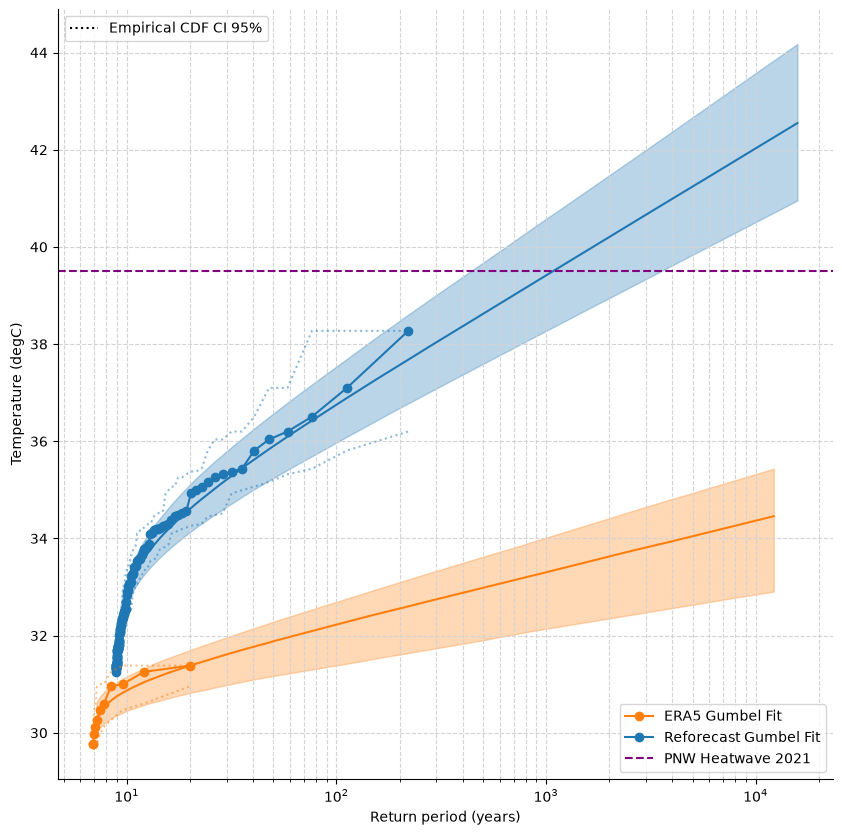

In [7]:
fig = plt.figure(figsize=(10, 10))

plt.plot(RP_era5, np.median(era5_curve, axis=1), color=color_era5)
plt.plot(RP_rfc, np.median(rfc_curve, axis=1), color=color_reforecast)

plt.fill_between(RP_era5.flatten(), *np.quantile(era5_curve, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_era5)
plt.fill_between(RP_rfc.flatten(), *np.quantile(rfc_curve, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_reforecast)

plt.plot(RP_obs, np.sort(top_e), color_era5, marker='o', label='ERA5 Gumbel Fit')
plt.plot(RP_obs_rfc, np.sort(top), color_reforecast, marker='o', label='Reforecast Gumbel Fit')

plt.plot(RP_obs, np.quantile(np.sort(era5_boot, axis=0), [0.025, 0.975], axis=1).T,
         color=color_era5, alpha=0.5, ls=':')
plt.plot(RP_obs_rfc, np.quantile(np.sort(reforecast_boot, axis=0), [0.025, 0.975], axis=1).T,
         color=color_reforecast, alpha=0.5, ls=':')

plt.xscale('log')
plt.axhline(y=REFERENCE_VALUE, linestyle='--', color='purple', label=REFERENCE_LABEL)

plt.xlabel('Return period (years)')
plt.ylabel('Temperature (degC)')

original_legend = plt.legend(loc='lower right')
additional_legend = plt.legend(
    handles=[plt.Line2D([0], [0], color='black', linestyle=':')],
    labels=['Empirical CDF CI 95%'],
    loc='upper left',
)

plt.grid(True, which='both', linestyle='--', color=grid_color)
plt.gca().add_artist(original_legend)

sns.despine()
plt.savefig('gumbel_lmom_return_periods.pdf', dpi=600)
plt.show()


## Notes / known limitations vs. the exact original PDF

- Return periods use the original notebook's `rate`/`x5` approach (Poisson
  POT correction, then rescaled by `RATE` again) for the underlying shape,
  plus a final *independent* rescale per series so ERA5's highest exceedance
  lands on 20 yr and the reforecast's lands on 220 yr. Because the two
  rescale factors differ, the reforecast curve sits at a different position
  relative to ERA5 than the single-shared-factor version did.
- The bias correction uses the corrected per-`inidate` slope/intercept values,
  now baked into `data/refore.csv` directly (see git history) -- this is what
  brings the reforecast exceedance magnitudes in line with the target figure
  (peak ~38.3 degC).
- `LEAD_DAYS=12` and `THRESHOLD_PERCENTILE=95` were hard-coded choices in the
  original analysis (not derived formulaically here) -- both are exposed at
  the top of this notebook so you can adjust them if your own methodology
  differs.
